# saltjax in 5 minutes

This page walks you through a complete `saltjax` session: simulate a few hundred Type Ia supernova
lightcurves, fit SALT2 to all of them at once with {func}`saltjax.fit_salt`, and check the results
against the truth. You will also see why the second fit of a session is much faster than the first.

:::{note}
The simulation uses [skysurvey](https://skysurvey.readthedocs.io). `saltjax` itself only needs two
pandas DataFrames, so you can use it on any lightcurves, simulated or real.
:::

In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from shapely import geometry

import skysurvey
import saltjax

## Simulate SNe Ia and a survey

We draw 500 SNe Ia up to $z=0.1$ in a patch of sky, with Milky Way extinction, and observe them with a
mock ZTF-like survey: 20,000 random pointings in the *g*, *r* and *i* bands with a constant sky noise,
so the signal-to-noise ratio drops with redshift.

In [2]:
snia = skysurvey.SNeIa.from_draw(size=500, zmax=0.1, tstart=59_000, tstop=59_150,
                                 radec={"ra_range": [150, 250], "dec_range": [-20, 30]},
                                 effect=skysurvey.effects.mw_extinction)

rng = np.random.default_rng(42)
npointings = 20_000
ra, dec = skysurvey.tools.utils.random_radec(size=npointings, ra_range=[150, 250],
                                             dec_range=[-20, 30], rng=rng)
logs = pd.DataFrame({"ra": ra, "dec": dec,
                     "mjd": rng.uniform(58_970, 59_200, size=npointings),
                     "band": rng.choice(["ztfg", "ztfr", "ztfi"], size=npointings),
                     "skynoise": rng.normal(600, 50, size=npointings),
                     "gain": 1, "zp": 30})
survey = skysurvey.Survey.from_pointings(logs, footprint=geometry.Point(0, 0).buffer(2))

Next we generate the lightcurves and keep the SNe with at least 7 detections.

In [3]:
dset = skysurvey.DataSet.from_targets_and_survey(snia, survey, seed=42)
ndet = dset.get_ndetection()
indexes = ndet.index[ndet >= 7]
print(f"{len(indexes)} SNe Ia with at least 7 detections")

478 SNe Ia with at least 7 detections


:::{note}
skysurvey target draws cannot be seeded, so the exact numbers on this page change a little from one run
to the next.
:::

## The two input tables

{func}`saltjax.fit_salt` takes two DataFrames. The first one holds the **lightcurves**. Its index has two levels,
(target, observation), and its columns are time (`time`, `mjd` or `jd`), `band`, `flux`, `fluxerr` and
`zp`. Fluxes are in the AB system.

In [4]:
dset.data.head()

mjd  band    skynoise  gain  zp  fieldid  \
index index_obs                                                      
0     11304      58970.832031  ztfi  626.742371     1  30   244287   
      60502      58974.859375  ztfi  547.731201     1  30   244287   
      71192      58975.542969  ztfg  564.346069     1  30   244287   
      71602      58975.570312  ztfg  656.630493     1  30   244287   
      143437     58981.031250  ztfi  608.197754     1  30   244287   

                        flux     fluxerr  
index index_obs                           
0     11304       190.979105  626.742371  
      60502      -569.631744  547.731201  
      71192       423.514192  564.346082  
      71602       617.603466  656.630485  
      143437    -1186.615207  608.197747

The second one holds the **targets**, one row per SN, with the same index as the first level of the
lightcurves. `saltjax` needs the redshift `z`, which stays fixed during the fit. It also uses `t0` to select
the data within `phase_range` and `mwebv` for the Milky Way extinction. Here `t0`, `x1` and `c` are the true values. We use them only to check the fit.

In [5]:
dset.targets.data.head()

,z,x1,c,t0,ra,dec,magabs,mwebv,magobs,template
0,0.05085,-2.130,-0.036,59002.667969,230.868683,-1.074495,-19.113966,0.111100,17.731464,salt2
1,0.08685,0.670,0.226,59008.093750,210.951431,-12.520587,-18.697964,0.085136,19.364017,salt2
2,0.03825,-1.435,0.035,59050.050781,230.806305,10.207593,-18.857075,0.040445,17.350422,salt2
3,0.06665,-2.390,-0.076,59010.183594,176.773575,-1.515423,-19.290392,0.023645,18.166702,salt2
4,0.08085,-0.105,-0.130,59121.191406,184.492462,1.718986,-19.658695,0.028382,18.239006,salt2


## Fit all the lightcurves

One call fits all the selected SNe. By default it includes the SALT2 model covariance in the
chi2, like `sncosmo.fit_lc(..., modelcov=True)`.

In [6]:
t_start = time.perf_counter()
results = saltjax.fit_salt(dset.data, dset.targets.data, indexes=indexes, progress_bar=True)
time_first = time.perf_counter() - t_start
print(f"first call: {time_first:.1f} s for {len(results)} SNe")

  0%|          | 0/478 [00:00<?, ?SN/s]

first call: 12.9 s for 478 SNe


In [7]:
results[["z", "t0", "x0", "x1", "c", "t0_err", "x0_err", "x1_err", "c_err",
         "chi2", "ndof", "converged"]].head()

,z,t0,x0,x1,c,t0_err,x0_err,x1_err,c_err,chi2,ndof,converged
0,0.05085,59002.642729,0.001301,-2.292963,-0.036149,0.204526,0.000038,0.215171,0.036917,1.036688,8.0,True
1,0.08685,59006.726485,0.000281,2.168978,0.203239,0.908255,0.000013,0.853847,0.050860,0.891686,4.0,True
2,0.03825,59050.191865,0.001829,-1.268809,0.027347,0.153107,0.000051,0.136213,0.027740,1.284650,5.0,True
3,0.06665,59011.469845,0.000761,-2.573367,0.001254,1.015108,0.000103,0.319854,0.097767,1.502849,6.0,True
4,0.08085,59121.489461,0.000794,-0.062566,-0.129937,0.349981,0.000023,0.174980,0.025424,12.433338,16.0,True


There is one row per fitted SN:

| columns | meaning |
|---|---|
| `t0`, `x0`, `x1`, `c` | best-fit SALT2 parameters |
| `t0_err`, ..., `c_err` | their 1-sigma errors |
| `cov_t0t0`, `cov_t0x0`, ... | the full 4x4 covariance matrix |
| `z`, `mwebv`, `mwr_v` | the fixed redshift and Milky Way dust |
| `chi2`, `ndof` | chi2 and number of degrees of freedom at the best fit |
| `converged`, `nrefit` | whether the model-covariance refits converged, and how many refits were done |

In [8]:
print(f"{results['converged'].mean():.1%} of the fits converged")

100.0% of the fits converged


:::{tip}
If you use skysurvey, the one-liner `skysurvey.lcfit.fit_salt_jax(dset)` does the same
fit directly on the `DataSet`.
:::

## Compare with the truth

Not every fit is usable. Some SNe have 7 detections in total but fewer than 4 points within
`phase_range`: their fit is under-constrained (`ndof <= 0`). A few low-S/N fits may also not converge,
or end where the chi2 is not curved upward, which gives NaN errors (this is why `saltjax` may print
warnings above). We keep the good fits and compare the fitted
parameters with the true ones (points are colored by redshift). The scatter grows with redshift as the S/N drops.

In [9]:
errors = results[["t0_err", "x0_err", "x1_err", "c_err"]]
good = (results["ndof"] > 0) & results["converged"] & np.isfinite(errors).all(axis=1)
print(f"{(~good).sum()} fits removed out of {len(results)}")
results = results[good]
truth = dset.targets.data.loc[results.index]

2 fits removed out of 478


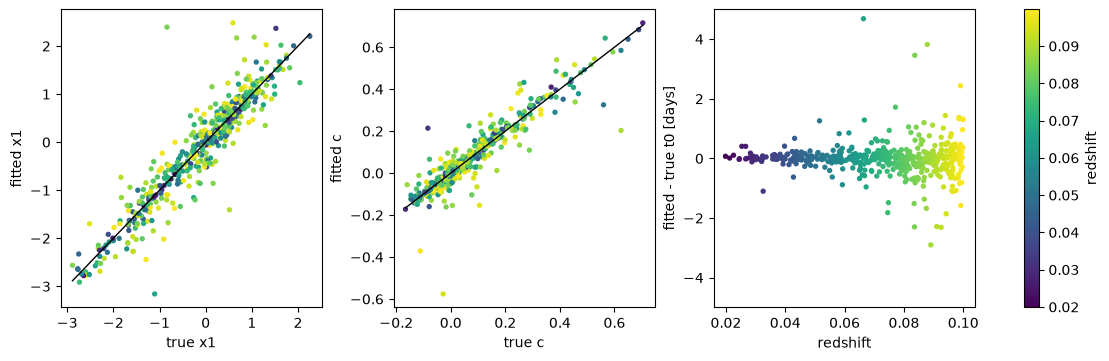

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.5), layout="constrained")
for ax, key in zip(axes[:2], ["x1", "c"]):
    ax.scatter(truth[key], results[key], c=truth["z"], s=8, cmap="viridis")
    lims = [truth[key].min(), truth[key].max()]
    ax.plot(lims, lims, color="k", lw=1)
    ax.set(xlabel=f"true {key}", ylabel=f"fitted {key}")
sc = axes[2].scatter(truth["z"], results["t0"] - truth["t0"], c=truth["z"], s=8, cmap="viridis")
axes[2].set(xlabel="redshift", ylabel="fitted - true t0 [days]", ylim=(-5, 5))
fig.colorbar(sc, ax=axes, label="redshift");

Pulls, (fitted - true) / error, show whether the errors are right. A few low-S/N fits can land on a wrong
minimum and give large pulls. We therefore measure the width with the normalized median absolute deviation
(NMAD), which ignores these outliers.

0 pulls with |pull| > 5 (out of 1428)


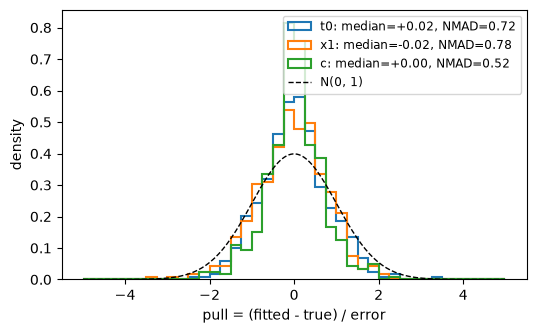

In [11]:
def nmad(x):
    return 1.4826 * np.nanmedian(np.abs(x - np.nanmedian(x)))

pulls = {k: (results[k] - truth[k]) / results[f"{k}_err"] for k in ["t0", "x1", "c"]}

fig, ax = plt.subplots(figsize=(6, 3.5))
bins = np.linspace(-5, 5, 41)
for key, pull in pulls.items():
    ax.hist(pull, bins=bins, histtype="step", lw=1.5, density=True,
            label=f"{key}: median={pull.median():+.2f}, NMAD={nmad(pull):.2f}")
xx = np.linspace(-5, 5, 200)
ax.plot(xx, np.exp(-xx**2 / 2) / np.sqrt(2 * np.pi), "k--", lw=1, label="N(0, 1)")
ax.set(xlabel="pull = (fitted - true) / error", ylabel="density")
ax.legend(fontsize="small");
n_out = sum(int((pull.abs() > 5).sum()) for pull in pulls.values())
print(f"{n_out} pulls with |pull| > 5 (out of {3 * len(results)})")

The pulls are narrower than a unit Gaussian for all three parameters. This is expected here: `modelcov=True`
adds the SALT2 model uncertainty to the errors, but these simulated lightcurves have no model scatter.
The `modelcov=False` fit below gives pulls of width close to 1.

## The second call is fast

The first call of a session does two extra things. It tabulates the SALT2 model, integrated through the
bandpasses on a redshift grid, and JAX compiles the fit. Both are cached: later calls with
similar data (same bands, similar redshift range and lightcurve lengths) reuse them and only do the fit.

In [12]:
t_start = time.perf_counter()
results_again = saltjax.fit_salt(dset.data, dset.targets.data, indexes=indexes)
time_second = time.perf_counter() - t_start
print(f"first call:  {time_first:.1f} s (tables + compilation + fit)")
print(f"second call: {time_second:.1f} s, i.e. {1e3 * time_second / len(results_again):.1f} ms per SN")

first call:  12.9 s (tables + compilation + fit)
second call: 1.9 s, i.e. 4.0 ms per SN


The [speed benchmark](./examples/speed.ipynb) compares this with sncosmo.

## Options worth knowing

| option | default | what it does |
|---|---|---|
| `modelcov` | `True` | include the SALT2 model covariance in the chi2 (as `sncosmo.fit_lc`). `False` uses the flux errors only, with no refit |
| `guess` | `"data"` | starting point: `"data"` scans t0 and c on a grid, `"truth"` starts from the `t0`, `x1`, `c` columns of `targets` |
| `phase_range` | `[-10, 40]` | rest-frame phases, relative to `targets["t0"]`, of the points used. `None` uses all the points |
| `minsnr` | `5` | SNe with no point at S/N >= `minsnr` are not fitted |
| `c_max` | `1.5` | the model is exact for \|c\| <= `c_max`. A warning is issued if a fit goes beyond |

For example, without the model covariance the pulls of our simulation have a width close to 1:

In [13]:
results_nocov = saltjax.fit_salt(dset.data, dset.targets.data, indexes=results.index,
                                 modelcov=False)
for key in ["t0", "x1", "c"]:
    pull = (results_nocov[key] - truth[key]) / results_nocov[f"{key}_err"]
    print(f"{key} pull: median={pull.median():+.2f}, NMAD={nmad(pull):.2f}")

t0 pull: median=+0.00, NMAD=1.04
x1 pull: median=+0.06, NMAD=0.91
c pull: median=+0.02, NMAD=0.98


:::{note}
`phase_range` is applied around `targets["t0"]`. For real data, give a rough `t0` estimate
(e.g. the date of peak flux) or use `phase_range=None`.
:::

## Next steps

- Coming from sncosmo? Read [saltjax for sncosmo users](./sncosmo_users/index.rst).
- See how closely `saltjax` reproduces `sncosmo.fit_lc` in the [validation](./examples/validation.ipynb).
- Compare the speed of the two in the [speed benchmark](./examples/speed.ipynb).
- Look up all the functions and options in the [API reference](./api/index.rst).